In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt

from src.data.market_loader import MarketLoader
from src.data.synthetic_sofr_builder import build_term_sofr_curve

from src.term_structure.curve_merger import merge_curves
from src.term_structure.bootstrapping import (
    build_coupon_structure,
    bootstrap_dfs_from_sofr,
    bootstrap_dfs_from_treasury
)
from src.term_structure.curve_interpolator import log_linear_curve_interpolator
from src.term_structure.curve_builder import (
    build_zero_curve,
    build_forward_curve
)

from src.visualization.curve_diagnostics import (
    plot_discount_curve,
    plot_zero_curve,
    plot_forward_curve,
    plot_curve_evolution
)

In [2]:
# downloading market curves
loader = MarketLoader()
curves = loader.loader_pipeline()

# building synthetic sofr curve from ON rates and futures
sofr_curve = build_term_sofr_curve(curves = curves)

# bootstrapping discount factors from sofr curve
df_sofr = bootstrap_dfs_from_sofr(
    sofr_curve = sofr_curve
)

# extracting treasury curve 
treasury_curve = curves['treasury']

# bootstrapping discount factors from treasury curve
df_treasury = bootstrap_dfs_from_treasury(
    treasury_curve = treasury_curve,
    short_dfs = df_sofr
)

# concatenating short-end and long-end into a single curve -> full curve
df_full_curve = merge_curves(
    short_curve = df_sofr,
    long_curve = df_treasury
)

# constructing semi-annual coupon structure
coupon_structure = build_coupon_structure(
    max_year = 30,
    freq = 2
)

# log-linear discount curve interpolation
df_loglinear_interp = log_linear_curve_interpolator(
    df_curve = df_full_curve,
    _target_times = coupon_structure
)

# building zero curve from log-linear discount curve
zero_curve_full = build_zero_curve(
    df_curve = df_loglinear_interp
)

# building forward curve from log-linear discount curve
forward_curve_full = build_forward_curve(
    df_curve = df_loglinear_interp
)

treasury curve dataset already downloaded..
sofr curve dataset already downloaded..
futures curve dataset already downloaded..


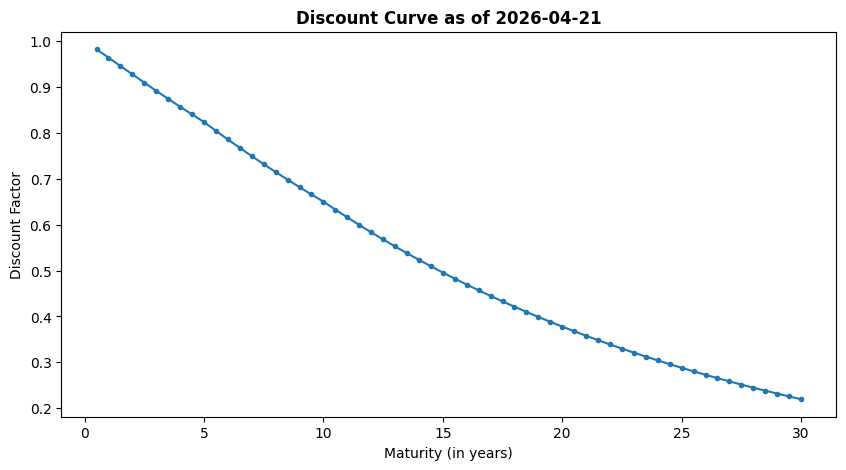

In [3]:
### curve diagnostics
# sample date
sample_date = df_loglinear_interp.index[-1]

plot_discount_curve(
    df_curve = df_loglinear_interp,
    date = sample_date
)


- DF curve starts around 1.0
- never takes negative values
- smooth downward slope

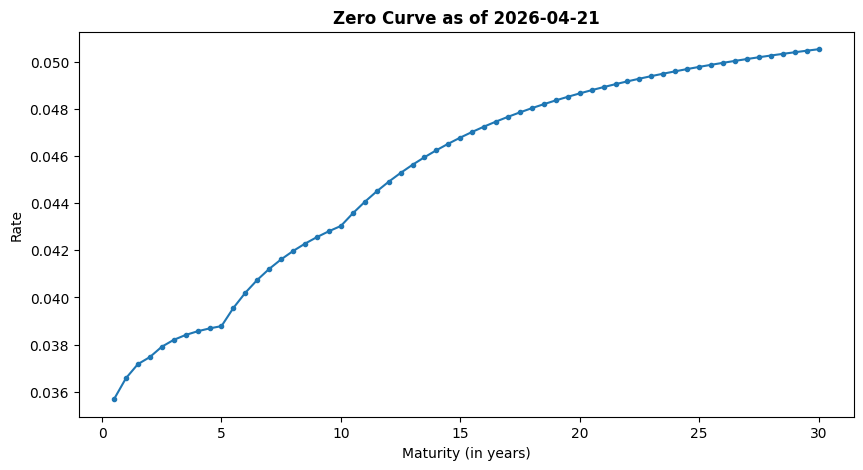

In [4]:
plot_zero_curve(
    zero_curve = zero_curve_full,   # type: ignore
    date = sample_date
)

- no major spikes observed across maturities
- ranges between expected values around 3.5% - 5.3% 

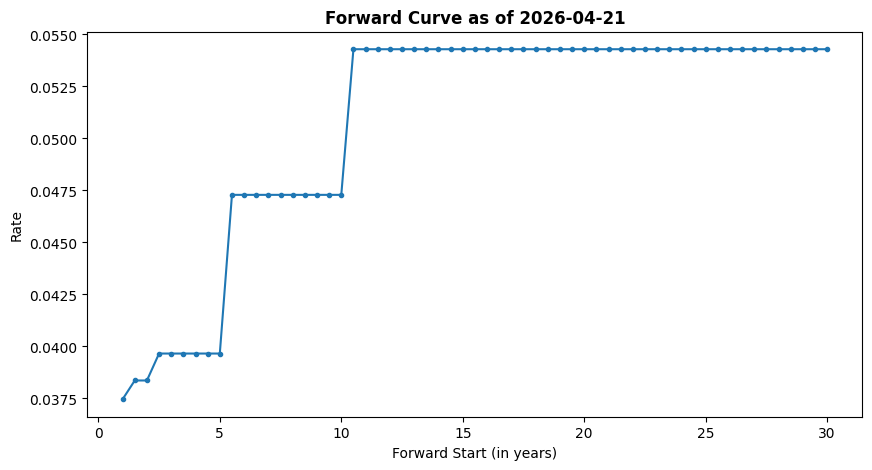

In [5]:
plot_forward_curve(
    forward_curve = forward_curve_full,
    date = sample_date
)

- observed piece-wise constant forwards with jumps at certain maturities -> interpolation artifact due to log-linear transformation
- ranges between expected values

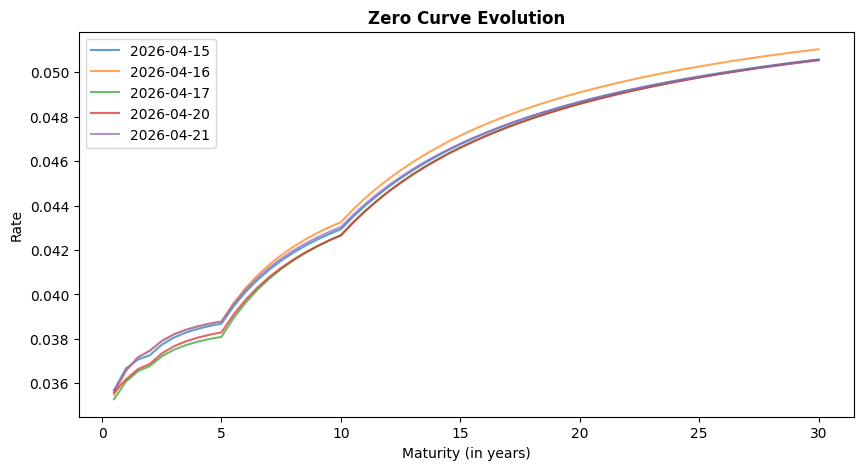

In [6]:
plot_curve_evolution(
    curve = zero_curve_full,
    curve_name = 'Zero',
    max_dates = 5
)